In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.model_selection import StratifiedGroupKFold

def stratified_group_split(df, label_col='tb_status', group_col='participant', test_size=0.2, random_state=42):
    sgkf = StratifiedGroupKFold(n_splits=int(1/test_size), shuffle=True, random_state=random_state)
    for train_idx, val_idx in sgkf.split(df, df[label_col], df[group_col]):
        df_train = df.iloc[train_idx].reset_index(drop=True)
        df_val = df.iloc[val_idx].reset_index(drop=True)
        return df_train, df_val

In [ ]:
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/longitudinal_original.csv')
df_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')
#df_solic['tb_status'] = df_solic['tb_status'].map({0: 3, 1: 4})

df_longi_train, df_longi_val = stratified_group_split(df_longi)
df_solic_train, df_solic_val = stratified_group_split(df_solic)

df_train = pd.concat([df_longi_train, df_solic_train], ignore_index=True)
df_val = pd.concat([df_longi_val, df_solic_val], ignore_index=True)

df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_val = df_val.sample(frac=1, random_state=42).reset_index(drop=True)


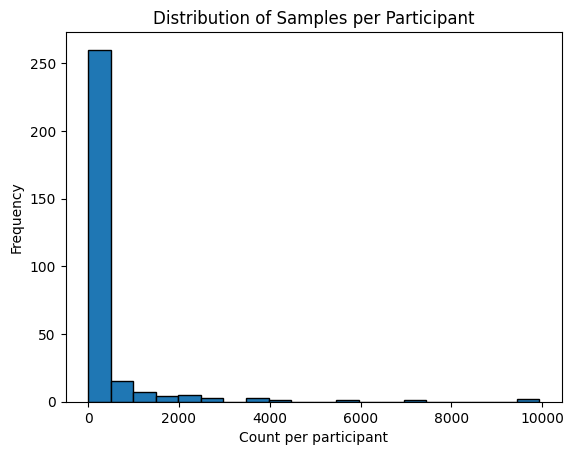

In [9]:
import matplotlib.pyplot as plt

df_val['participant'].value_counts().plot(kind='hist', bins=20, edgecolor='black')
plt.xlabel('Count per participant')
plt.ylabel('Frequency')
plt.title('Distribution of Samples per Participant')
plt.show()


In [6]:
df_longi['participant'].value_counts()

participant
CODA_TB_1013    62750
CODA_TB_1034    20142
CODA_TB_0562    15404
CODA_TB_0244    14517
CODA_TB_0469    12937
                ...  
CODA_TB_0131        1
CODA_TB_1023        1
CODA_TB_0008        1
CODA_TB_1033        1
CODA_TB_0009        1
Name: count, Length: 556, dtype: int64

In [7]:
assert not set(df_longi_train['participant']) & set(df_longi_val['participant'])
assert not set(df_soliic_train['participant']) & set(df_soliic_val['participant'])

print(df_soliic_train['tb_status'].value_counts(normalize=True))
print(df_soliic_val['tb_status'].value_counts(normalize=True))

tb_status
0    0.701327
1    0.298673
Name: proportion, dtype: float64
tb_status
0    0.700441
1    0.299559
Name: proportion, dtype: float64


In [9]:
df_soliic_val

,participant,filename,sound_prediction_score,sex,age,height,weight,reported_cough_dur,tb_prior,tb_prior_Pul,...,hemoptysis,heart_rate,temperature,weight_loss,smoke_lweek,fever,night_sweats,tb_status,tb_type,path_file
0,CODA_TB_0002,1643791257235-recording-1.wav,0.990237,Female,48,163.0,49.9,16,Yes,Yes,...,No,80,36.6,Yes,No,No,Yes,1,3,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...
1,CODA_TB_0002,1643791282515-recording-1.wav,0.984813,Female,48,163.0,49.9,16,Yes,Yes,...,No,80,36.6,Yes,No,No,Yes,1,3,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...
2,CODA_TB_0002,1643791201453-recording-1.wav,0.989808,Female,48,163.0,49.9,16,Yes,Yes,...,No,80,36.6,Yes,No,No,Yes,1,3,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...
3,CODA_TB_0002,1643791203573-recording-1.wav,0.990205,Female,48,163.0,49.9,16,Yes,Yes,...,No,80,36.6,Yes,No,No,Yes,1,3,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...
4,CODA_TB_0002,1643791177587-recording-1.wav,0.990183,Female,48,163.0,49.9,16,Yes,Yes,...,No,80,36.6,Yes,No,No,Yes,1,3,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1811,CODA_TB_1107,1658214018804-recording-1.wav,0.941761,Female,50,174.0,87.3,30,No,No,...,No,70,37.0,No,No,Yes,No,0,0,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...
1812,CODA_TB_1107,1658213992939-recording-1.wav,0.904569,Female,50,174.0,87.3,30,No,No,...,No,70,37.0,No,No,Yes,No,0,0,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...
1813,CODA_TB_1107,1658213992139-recording-1.wav,0.934713,Female,50,174.0,87.3,30,No,No,...,No,70,37.0,No,No,Yes,No,0,0,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...
1814,CODA_TB_1107,1658213940569-recording-1.wav,0.912813,Female,50,174.0,87.3,30,No,No,...,No,70,37.0,No,No,Yes,No,0,0,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...


In [ ]:


participant_col = "participant"
label_col = "tb_status"

test_participants_df = (
    df_test.groupby(participant_col)[label_col]
    .agg(lambda x: x.mode()[0]) 
    .reset_index()
)

val_participants, _ = train_test_split(
    test_participants_df[participant_col],
    test_size=0.8,
    stratify=test_participants_df[label_col],
    random_state=42
)

df_val = df_train[df_train[participant_col].isin(val_participants)]
df_train = df_train[~df_train[participant_col].isin(val_participants)]
df_test = pd.concat([df_val, df_test], ignore_index=True)

cols = ["path_file", "tb_status"]
df_train = df_train[cols]
df_test = df_test[cols]

counts = df_train['tb_status'].value_counts()
min_class = counts.idxmin()
max_class = counts.idxmax()
df_min = df_train[df_train.tb_status == min_class]
df_max = df_train[df_train.tb_status == max_class]
df_max_down = resample(df_max,
                       replace=False,
                       n_samples=len(df_min),
                       random_state=42)
df_train = pd.concat([df_min, df_max_down]).sample(frac=1, random_state=42).reset_index(drop=True)

counts = df_test['tb_status'].value_counts()
min_class = counts.idxmin()
max_class = counts.idxmax()
df_min = df_test[df_test.tb_status == min_class]
df_max = df_test[df_test.tb_status == max_class]
df_max_down = resample(df_max,
                       replace=False,
                       n_samples=len(df_min),
                       random_state=42)
df_test = pd.concat([df_min, df_max_down]).sample(frac=1, random_state=42).reset_index(drop=True)

In [19]:
df_test['tb_status'].value_counts()

tb_status
1    52598
0    52598
Name: count, dtype: int64